### The Hebbian and Anti-Hebbian Neural Network, 2 layers

The new network will have two parts:
- In their first layer, the neurons will be connected with a weight matrix \( W \) between output neurons \( y \) and input neurons \( x \).
$$
\mathbf{y = Wx \in \mathbb{R}^m}
$$
- In their second layer, the output neurons \( y \) will conduct inhibition using between each other with a weight matrix \( V \).
$$
\mathbf{y = Wx + Vy \in \mathbb{R}^m}
$$

The first layer is a Hebbian network, while the second layer is an Anti-Hebbian network.
The equation to update the weights $\mathbf{W}$ is the same as the Hebbian network, while the equation to update the weights $\mathbf{V}$ is the same as the Anti-Hebbian network.

For symmetric, Oja's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = - \gamma (yy^T)}
$$

For asymmetric, Sanger's rule setting:
$$
\mathbf{\Delta W = \eta (yx^T - y^2 W)}
$$

$$
\mathbf{\Delta V = \gamma (yy^T - y^2 V_B), V_B = tril(V)}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hebbian.models import HebbianModel, OjaNetwork, SangerNetwork, FoldiakPCA
from hebbian.utils import training_testing
from typing import Any, Optional
import pandas as pd

### Test case 2D

In [2]:
from hebbian.utils import generate_covariance_matrix, instantiate_samples_by_cov, plot_samples_and_top2_pcs
N = 2
m = 2
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_2d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

### Test case 3D

In [3]:
N = 3
m = 3
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([10.0, 4.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_3d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)


### Test case 10D

In [4]:
N = 64
m = 4
n_samples = 10001
X_seed = 0
# get /sigma
eigenvalues = np.array([20., 15., 4.0, 0.8])  # Your desired eigenvalues

# eigenvalues = np.array([12.0, 5.0, 3.0, 1.8, 1.0, 0.3, 0.1, 0.05])  # Your desired eigenvalues
Sigma = generate_covariance_matrix(dim=m, eigenvalues=eigenvalues, method="eigenvalues")

samples_10d = instantiate_samples_by_cov(Sigma, N, m, seed=X_seed, n_samples=n_samples)

### Testing alignment to the first PC, applying to all output neurons.

run  1
step    0 | order = [3 0 2 1] | best|corr|= [0.222 0.171 0.087 0.186]
step 1000 | order = [3 0 2 1] | best|corr|= [0.225 0.38  0.109 0.363]
step 2000 | order = [3 0 2 1] | best|corr|= [0.241 0.695 0.128 0.617]
step 3000 | order = [3 0 2 1] | best|corr|= [0.253 0.838 0.141 0.824]
step 4000 | order = [3 0 2 1] | best|corr|= [0.265 0.868 0.151 0.901]
step 5000 | order = [3 0 2 1] | best|corr|= [0.276 0.896 0.157 0.9  ]
step 6000 | order = [3 0 2 1] | best|corr|= [0.288 0.835 0.157 0.949]
step 7000 | order = [2 0 3 1] | best|corr|= [0.295 0.873 0.179 0.927]
step 8000 | order = [2 0 3 1] | best|corr|= [0.321 0.887 0.203 0.916]
step 9000 | order = [2 0 3 1] | best|corr|= [0.351 0.865 0.227 0.931]
step 10000 | order = [2 0 3 1] | best|corr|= [0.39  0.899 0.248 0.903]


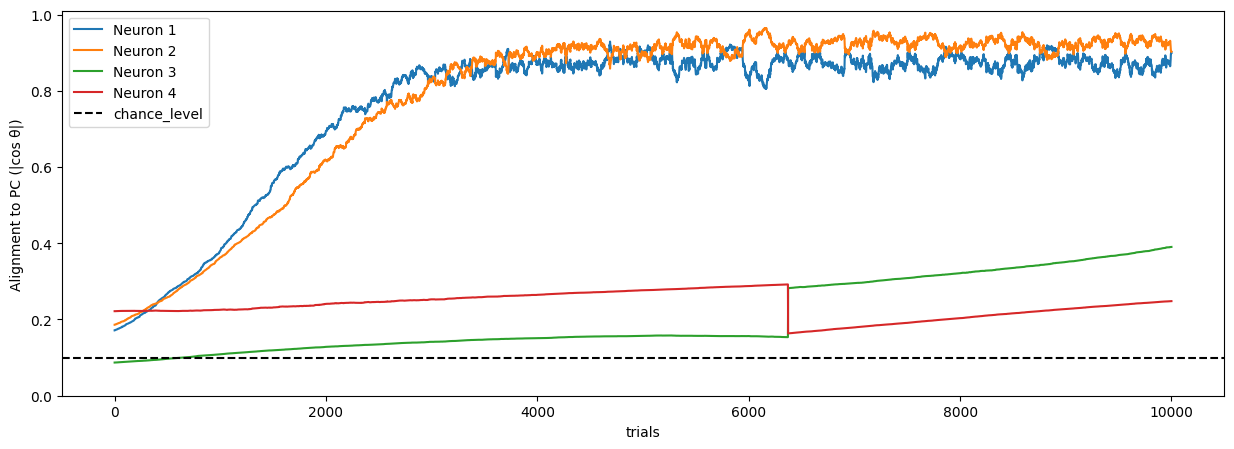

run  2
step    0 | order = [2 3 0 1] | best|corr|= [0.15  0.073 0.261 0.173]
step 1000 | order = [2 3 0 1] | best|corr|= [0.17  0.062 0.333 0.362]
step 2000 | order = [3 2 0 1] | best|corr|= [0.015 0.252 0.59  0.601]
step 3000 | order = [3 2 0 1] | best|corr|= [0.028 0.257 0.728 0.741]
step 4000 | order = [3 2 0 1] | best|corr|= [0.038 0.262 0.735 0.804]
step 5000 | order = [3 2 0 1] | best|corr|= [0.048 0.264 0.785 0.781]
step 6000 | order = [3 2 0 1] | best|corr|= [0.057 0.267 0.689 0.863]
step 7000 | order = [3 2 0 1] | best|corr|= [0.066 0.273 0.743 0.825]
step 8000 | order = [3 2 0 1] | best|corr|= [0.074 0.289 0.755 0.815]
step 9000 | order = [3 2 0 1] | best|corr|= [0.082 0.317 0.733 0.829]
step 10000 | order = [3 2 0 1] | best|corr|= [0.088 0.368 0.766 0.802]


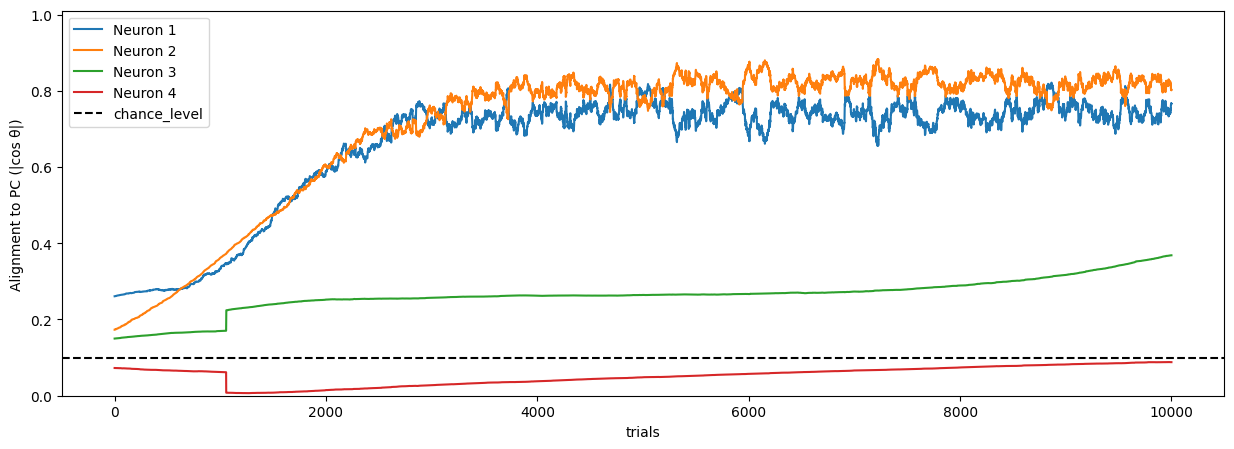

run  3
step    0 | order = [2 0 3 1] | best|corr|= [0.1   0.282 0.152 0.229]
step 1000 | order = [2 0 1 3] | best|corr|= [0.16  0.306 0.277 0.112]
step 2000 | order = [2 0 1 3] | best|corr|= [0.191 0.536 0.332 0.148]
step 3000 | order = [2 0 1 3] | best|corr|= [0.218 0.762 0.593 0.147]
step 4000 | order = [2 0 1 3] | best|corr|= [0.249 0.853 0.8   0.139]
step 5000 | order = [2 0 1 3] | best|corr|= [0.28  0.872 0.872 0.135]
step 6000 | order = [2 0 1 3] | best|corr|= [0.307 0.837 0.912 0.143]
step 7000 | order = [2 0 1 3] | best|corr|= [0.329 0.848 0.902 0.153]
step 8000 | order = [2 0 1 3] | best|corr|= [0.351 0.851 0.89  0.164]
step 9000 | order = [2 0 1 3] | best|corr|= [0.399 0.839 0.904 0.173]
step 10000 | order = [2 0 1 3] | best|corr|= [0.471 0.862 0.88  0.185]


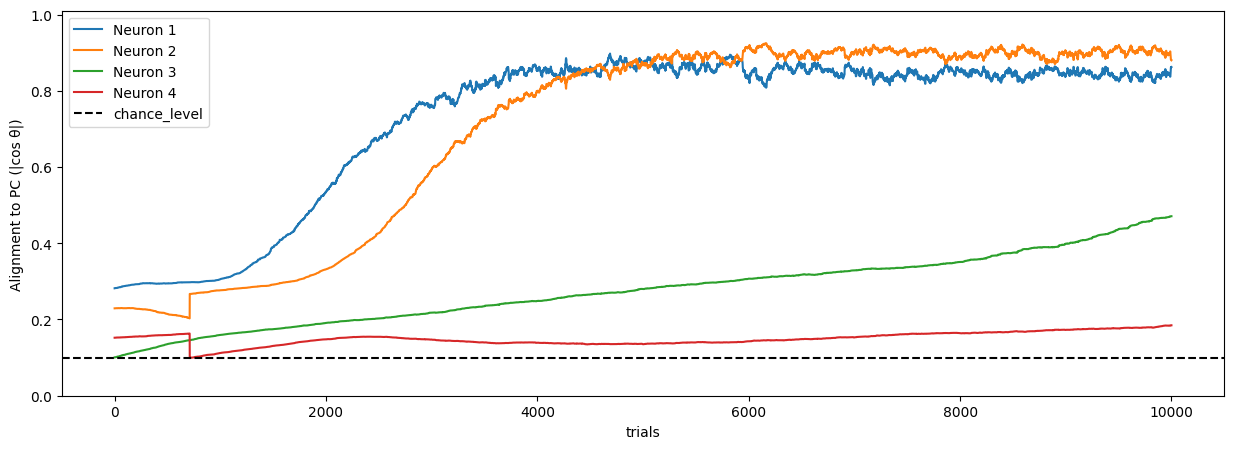

run  4
step    0 | order = [0 2 1 3] | best|corr|= [0.11  0.034 0.165 0.057]
step 1000 | order = [0 2 1 3] | best|corr|= [0.161 0.047 0.308 0.052]
step 2000 | order = [0 2 1 3] | best|corr|= [0.096 0.055 0.5   0.041]
step 3000 | order = [3 2 1 0] | best|corr|= [0.022 0.049 0.662 0.111]
step 4000 | order = [3 2 0 1] | best|corr|= [0.026 0.053 0.674 0.223]
step 5000 | order = [3 2 0 1] | best|corr|= [0.01  0.065 0.696 0.479]
step 6000 | order = [2 3 1 0] | best|corr|= [0.069 0.02  0.781 0.511]
step 7000 | order = [2 3 0 1] | best|corr|= [0.087 0.021 0.638 0.71 ]
step 8000 | order = [2 3 0 1] | best|corr|= [0.108 0.022 0.642 0.716]
step 9000 | order = [2 3 1 0] | best|corr|= [0.114 0.023 0.753 0.6  ]
step 10000 | order = [2 3 0 1] | best|corr|= [0.134 0.023 0.648 0.709]


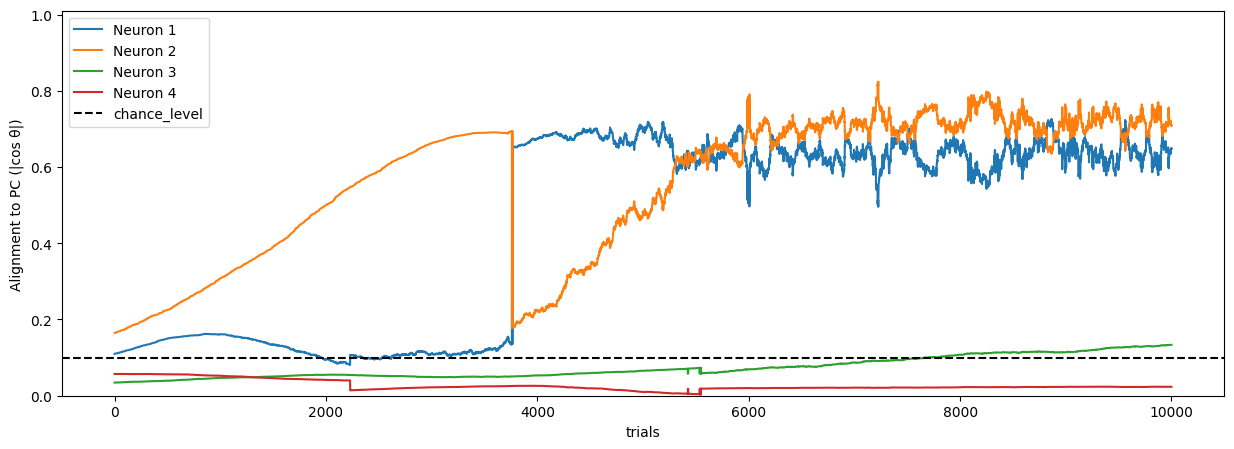

run  5
step    0 | order = [2 1 0 3] | best|corr|= [0.289 0.233 0.08  0.098]
step 1000 | order = [2 1 0 3] | best|corr|= [0.321 0.395 0.123 0.105]
step 2000 | order = [2 1 0 3] | best|corr|= [0.333 0.627 0.192 0.108]
step 3000 | order = [2 1 0 3] | best|corr|= [0.368 0.835 0.343 0.109]
step 4000 | order = [2 1 0 3] | best|corr|= [0.485 0.939 0.721 0.108]
step 5000 | order = [2 1 0 3] | best|corr|= [0.582 0.96  0.908 0.111]
step 6000 | order = [2 1 0 3] | best|corr|= [0.659 0.984 0.919 0.115]
step 7000 | order = [2 1 0 3] | best|corr|= [0.734 0.972 0.941 0.12 ]
step 8000 | order = [2 1 0 3] | best|corr|= [0.798 0.965 0.952 0.127]
step 9000 | order = [2 1 0 3] | best|corr|= [0.854 0.974 0.927 0.134]
step 10000 | order = [2 1 0 3] | best|corr|= [0.895 0.958 0.956 0.141]


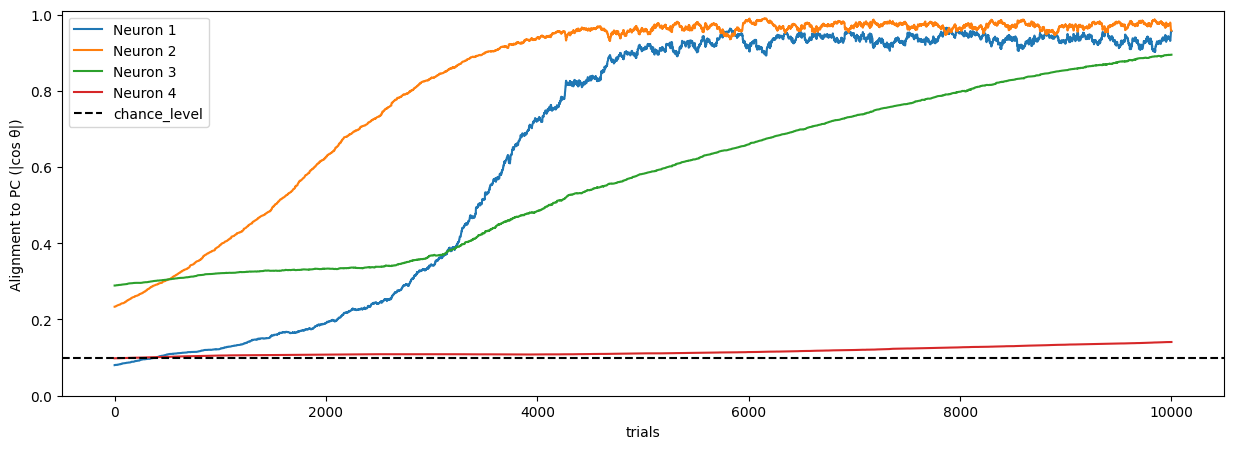

run  6
step    0 | order = [0 1 2 3] | best|corr|= [0.102 0.138 0.129 0.126]
step 1000 | order = [0 1 2 3] | best|corr|= [0.156 0.242 0.186 0.125]
step 2000 | order = [2 1 0 3] | best|corr|= [0.238 0.338 0.209 0.121]
step 3000 | order = [2 1 0 3] | best|corr|= [0.309 0.525 0.405 0.122]
step 4000 | order = [2 1 0 3] | best|corr|= [0.355 0.785 0.629 0.121]
step 5000 | order = [2 1 0 3] | best|corr|= [0.408 0.813 0.762 0.127]
step 6000 | order = [2 1 0 3] | best|corr|= [0.478 0.884 0.73  0.14 ]
step 7000 | order = [2 1 0 3] | best|corr|= [0.561 0.861 0.75  0.154]
step 8000 | order = [2 1 0 3] | best|corr|= [0.637 0.863 0.747 0.166]
step 9000 | order = [2 1 0 3] | best|corr|= [0.715 0.867 0.729 0.179]
step 10000 | order = [2 1 0 3] | best|corr|= [0.785 0.862 0.735 0.192]


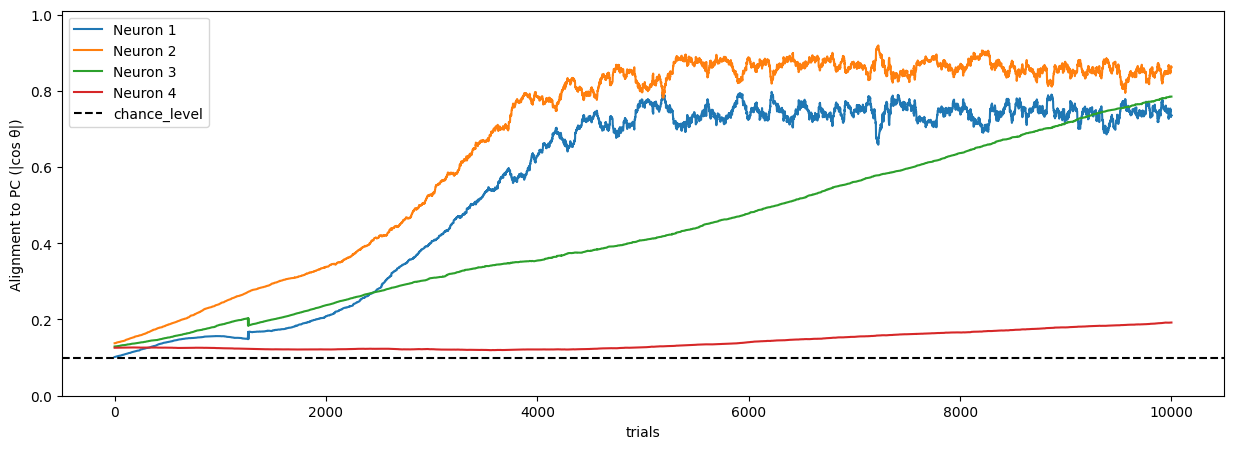

run  7
step    0 | order = [0 1 3 2] | best|corr|= [0.081 0.11  0.177 0.076]
step 1000 | order = [0 1 3 2] | best|corr|= [0.188 0.212 0.192 0.093]
step 2000 | order = [0 1 3 2] | best|corr|= [0.344 0.368 0.231 0.113]
step 3000 | order = [0 1 3 2] | best|corr|= [0.654 0.638 0.247 0.135]
step 4000 | order = [0 1 3 2] | best|corr|= [0.905 0.871 0.229 0.165]
step 5000 | order = [0 1 3 2] | best|corr|= [0.963 0.959 0.228 0.188]
step 6000 | order = [0 1 3 2] | best|corr|= [0.971 0.98  0.229 0.202]
step 7000 | order = [0 1 3 2] | best|corr|= [0.966 0.986 0.234 0.208]
step 8000 | order = [0 1 3 2] | best|corr|= [0.959 0.989 0.239 0.206]
step 9000 | order = [0 1 3 2] | best|corr|= [0.961 0.986 0.247 0.189]
step 10000 | order = [0 1 3 2] | best|corr|= [0.951 0.988 0.256 0.174]


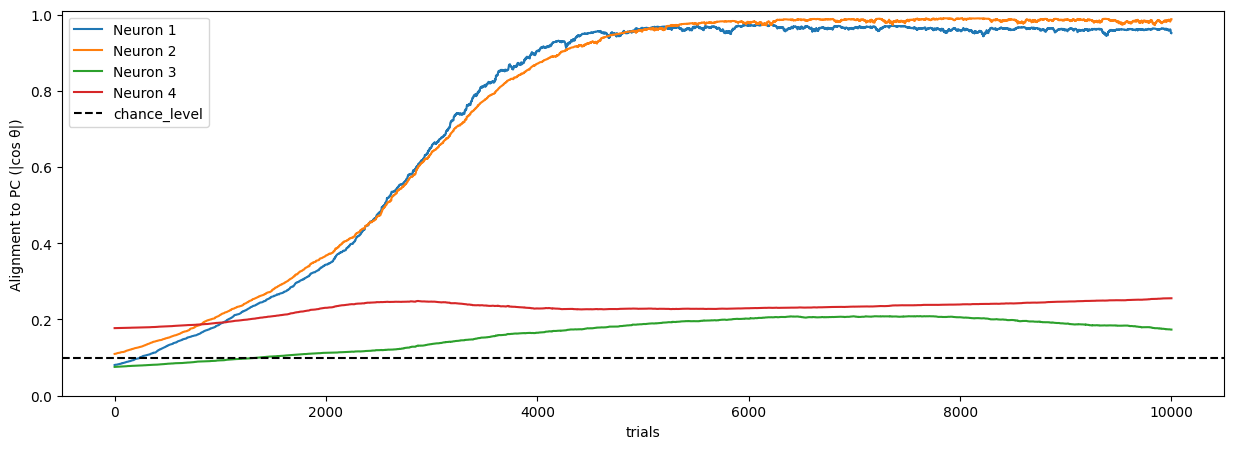

run  8
step    0 | order = [0 1 3 2] | best|corr|= [0.164 0.194 0.105 0.203]
step 1000 | order = [0 1 3 2] | best|corr|= [0.253 0.322 0.118 0.241]
step 2000 | order = [0 1 3 2] | best|corr|= [0.458 0.577 0.129 0.281]
step 3000 | order = [0 1 3 2] | best|corr|= [0.697 0.78  0.146 0.324]
step 4000 | order = [0 1 3 2] | best|corr|= [0.765 0.867 0.154 0.368]
step 5000 | order = [0 1 3 2] | best|corr|= [0.814 0.858 0.164 0.42 ]
step 6000 | order = [0 1 3 2] | best|corr|= [0.739 0.926 0.171 0.48 ]
step 7000 | order = [0 1 3 2] | best|corr|= [0.787 0.893 0.179 0.551]
step 8000 | order = [0 1 3 2] | best|corr|= [0.801 0.883 0.186 0.629]
step 9000 | order = [0 1 3 2] | best|corr|= [0.777 0.901 0.189 0.706]
step 10000 | order = [0 1 3 2] | best|corr|= [0.808 0.871 0.19  0.776]


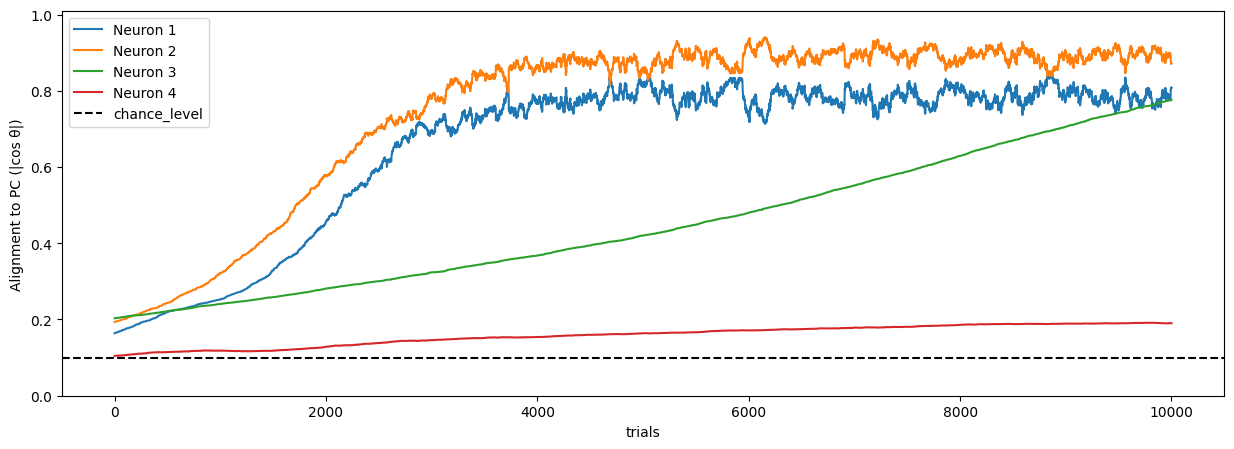

run  9
step    0 | order = [2 0 3 1] | best|corr|= [0.346 0.096 0.263 0.031]
step 1000 | order = [2 0 1 3] | best|corr|= [0.41  0.146 0.208 0.129]
step 2000 | order = [1 2 0 3] | best|corr|= [0.439 0.238 0.444 0.144]
step 3000 | order = [1 2 0 3] | best|corr|= [0.619 0.329 0.684 0.156]
step 4000 | order = [1 2 0 3] | best|corr|= [0.808 0.336 0.812 0.164]
step 5000 | order = [1 2 0 3] | best|corr|= [0.864 0.354 0.858 0.174]
step 6000 | order = [1 2 0 3] | best|corr|= [0.932 0.393 0.818 0.182]
step 7000 | order = [1 2 0 3] | best|corr|= [0.916 0.456 0.852 0.191]
step 8000 | order = [1 2 0 3] | best|corr|= [0.911 0.522 0.866 0.198]
step 9000 | order = [1 2 0 3] | best|corr|= [0.926 0.611 0.852 0.204]
step 10000 | order = [1 2 0 3] | best|corr|= [0.903 0.695 0.867 0.211]


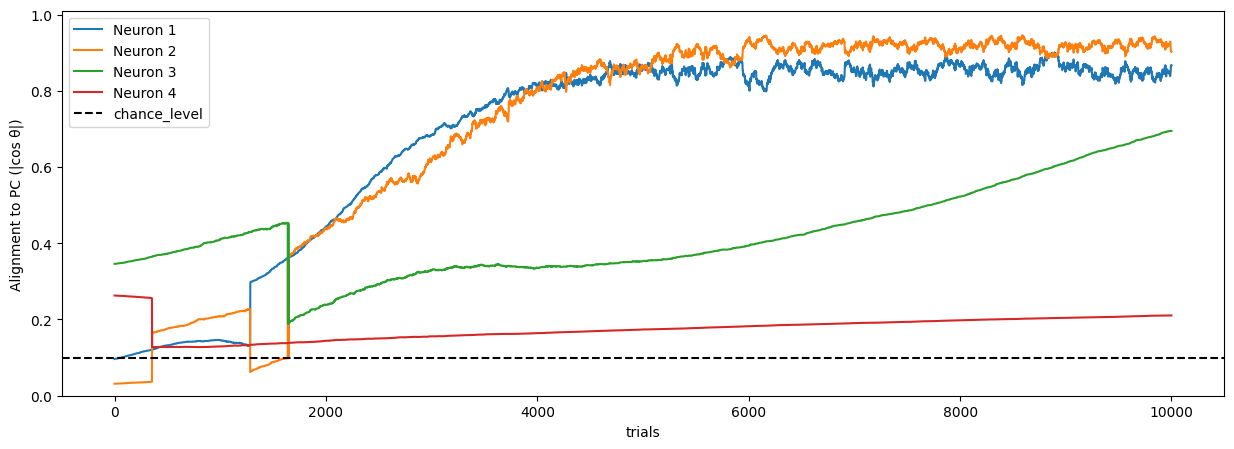

run 10
step    0 | order = [0 2 1 3] | best|corr|= [0.105 0.145 0.107 0.08 ]
step 1000 | order = [0 2 1 3] | best|corr|= [0.221 0.167 0.163 0.077]
step 2000 | order = [0 2 1 3] | best|corr|= [0.436 0.228 0.218 0.083]
step 3000 | order = [0 2 1 3] | best|corr|= [0.722 0.333 0.315 0.101]
step 4000 | order = [0 2 1 3] | best|corr|= [0.872 0.419 0.486 0.104]
step 5000 | order = [0 2 1 3] | best|corr|= [0.916 0.484 0.694 0.105]
step 6000 | order = [0 2 1 3] | best|corr|= [0.89  0.549 0.811 0.109]
step 7000 | order = [0 2 1 3] | best|corr|= [0.911 0.616 0.845 0.112]
step 8000 | order = [0 2 1 3] | best|corr|= [0.922 0.686 0.857 0.114]
step 9000 | order = [0 2 1 3] | best|corr|= [0.899 0.758 0.865 0.12 ]
step 10000 | order = [0 2 1 3] | best|corr|= [0.931 0.823 0.841 0.126]


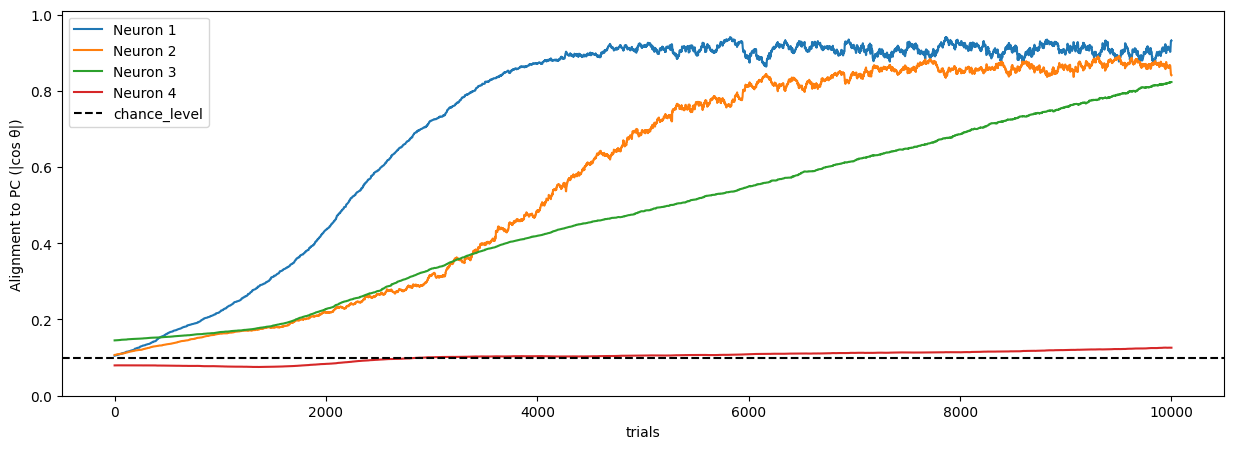

<Figure size 640x480 with 0 Axes>

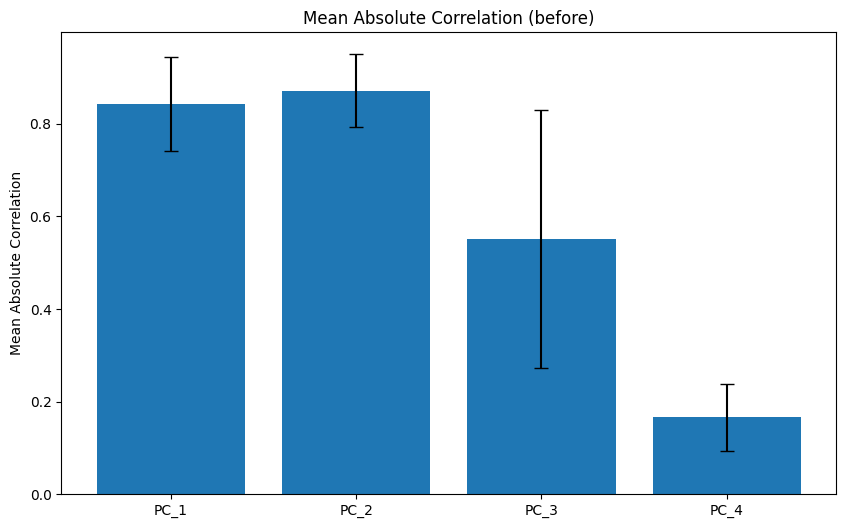

In [5]:
model_paras = {
    "input_size": N,
    "output_size": m,
    "eta_w": 5e-5,
    "eta_v": 5e-4
}

model = FoldiakPCA(**model_paras)

training_testing(model, samples_10d, m, runs=10)